# Titanic Survival Prediction using Logistic Regression

This project builds a machine learning pipeline to predict passenger survival on the Titanic using logistic regression. 

 1. Load Dataset
 2. Basic Inspection
 3. Missing Value Handling
 4. Feature Engineering+ Encoding
 5. Selecting Features
 6. Train-Test Split
 7. Feature Scaling
 8. Train Logistic Regression
 9. Generate Prediction
 10. Model Evaluation
 11. ROC Curve and AUC
 12. Prediction on Kaggle Test Data
 13. Final Kaggle Submission


---
 **Import Libraries**

In [122]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

---
1. Load Dataset

In [123]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


- SibSp: Number of siblings/spouses aboard -> Shows family size
- Parch: Number of parents/children aboard -> indicates family size
- Cabin: Cabin number (e.g., C85)
- Embarked: Port where passenger boarded

---
2. Basic Inspection: We inspect the dataset to understand missing values, data types, and feature structure before preprocessing.

In [124]:
df.info() # Show a summary of the dataset: number of rows and columns, column names, non-null counts, data types (int, float, object)
df.isnull().sum() # Count missing values in each column:

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

---
3. Missing Value Handling: We handle missing values by:

- Filling Age with the median, since it is more robust to outliers than the mean.
- Filling Embarked with the mode, because it is a categorical feature and the most frequent value is a reasonable choice.
- Dropping Cabin due to the large number of missing values, which makes reliable imputation difficult.

In [125]:
age_median = df["Age"].median()#fillna(): Fill missing values (NaN) with something
embarked_mode = df["Embarked"].mode()[0]# mode returns a pair: index, mode-like: 0   S, 1   C. [0] says return the first mode
fare_median=df["Fare"].median() # to use for test, we dont have missing fare in training data
# I calculated them to use them later to handle missing in test file
df["Age"] = df["Age"].fillna(age_median)
df["Embarked"] = df["Embarked"].fillna(embarked_mode) 
df.drop(columns=["Cabin"], inplace=True)

---
4. Feature Engineering: We create new, more informative features from the existing raw data so the model can learn stronger and more meaningful patterns.

    4.1 Reveal hidden signals, reduce noise, and simplify relationships: We design features such as family size, is alone, title, and fare per person to better capture social grouping, passenger status, and individual wealth, all of which are more directly related to survival behavior than the raw columns alone.
    
    4.2 Encode categorical features: We convert categorical variables into numerical format using one-hot encoding so that logistic regression can process them effectively.

---
4.1. Note that survival was often influenced by whether someone was traveling alone or with a group because people in families may have tried to stay together or help each other, while larger groups could either improve coordination or slow down escape. Based on this idea, we engineer the following features: 
- “family size”, where we combine siblings and parents into a single measure to capture the overall group size a passenger was traveling with
- “is alone”, which explicitly identifies passengers without any family onboard, since being alone could reduce support and increase vulnerability during evacuation
- “title”, extracted from names because titles like Mr, Mrs, Miss, and Dr carry hidden information about gender, age, and social status, all of which influenced survival priority in lifeboats
- “fare per person”, because total fare can be misleading for groups, while dividing it per person gives a better estimate of individual wealth, which is more directly related to survival chances.

In [126]:
# Extract title once
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False) #extract a pattern " space+alphabet+.", expand=false means Return a single column (not a table)

# Family features
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Fare feature
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

# Clean titles



df["Title"] = df["Title"].replace(["Mlle", "Ms"], "Miss")
df["Title"] = df["Title"].replace(["Mme"], "Mrs")
common_titles = ["Mr", "Mrs", "Miss"]
df["Title"] = df["Title"].apply(lambda x: x if x in common_titles else "Rare")

>Note: " [A-Za-z]+"	means a space following one or more letters (A–Z or a–z) and \.	a literal dot, because this is the pattern of title Mr., Miss. etc


---
4.2. Encode Categorical Features: For a categorical feature with k categories, one-hot encoding creates k dummy columns. When drop_first=True, it keeps only k − 1 columns by removing one reference category to avoid redundancy. For example, instead of the Sex column, one-hot encoding would normally create Sex_male and Sex_female. With drop_first=True, only one of them is kept (for example Sex_male), and the missing category is implicitly represented when the value is 0.

In [127]:
df = pd.get_dummies(df, columns=["Sex", "Embarked", "Title"], drop_first=True)# remove those columns and replace each with k-1 dummy features.

---
5. Selecting Features: We drop irrelevant or less informative features that do not contribute meaningfully to survival prediction.

In [128]:
X = df.drop(["Survived", "Name", "Ticket", "PassengerId","SibSp", "Parch"], axis=1) #axis=1 means remove columns with thise names, 0: delete rows
y = df["Survived"]


---
6. Train/Test Split

In [129]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=.2, random_state=40)

---
7. Feature Scaling: We standardize numerical features so they follow a common scale, ensuring that all variables contribute more equally to the logistic regression model.

In [130]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

---
8. Train logestic Regression

In [131]:
model=LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

---
9. Generate Predictions: Use the trained logistic regression model to predict passenger survival on test data.

In [132]:
y_pred=model.predict(X_test)

---
10. Model Evaluation:  Confusion Matrix includes: TP = correct yes, TN = correct no, FP = false alarm, FN = missed positive

    In Titanic example, positive = survived:

    - TP → predicted survived, actually survived
    - TN → predicted died, actually died
    - FP → predicted survived, actually died
    - FN → predicted died, actually survived
    
    We evaluate the logistic regression model using a confusion matrix and derive key performance metrics:

    - Precision: Measures how many predicted survivors are actually correct.
    - Recall: Measures how many actual survivors are correctly identified by the model.
    - Specificity: Measures how many non-survivors are correctly classified.
    - F1 Score: A harmonic balance between precision and recall.

    These metrics provide a more complete understanding of model performance beyond accuracy, especially in cases where class distribution or error types matter. 



In [133]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm[0,0],cm[0,1], cm[1,0], cm[1,1]
print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

accuracy=(tn+tp)/(tn+tp+fn+fp)
presicion=tp/(tp+fp)
recall=tp/(tp+fn)
specificity=tn/(tn+fp)
fpr=1-specificity
f1=2.0/((1.0/presicion)+(1.0/recall))
print("Accuracy:", accuracy)
print("Precision:", presicion)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1 Score:", f1)
print("FPR:",fpr)

TN: 87 FP: 16 FN: 14 TP: 62
Accuracy: 0.8324022346368715
Precision: 0.7948717948717948
Recall: 0.8157894736842105
Specificity: 0.8446601941747572
F1 Score: 0.8051948051948052
FPR: 0.15533980582524276


---
11. ROC Curve and AUC: We evaluate the logistic regression model across all possible classification thresholds using the ROC curve.
- The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate at different decision thresholds, showing the trade-off between correctly identifying survivors and incorrectly classifying non-survivors.
- The AUC (Area Under the Curve) summarizes the ROC curve into a single value that measures how well the model can distinguish between survivors and non-survivors. A higher AUC indicates better ranking and classification performance across all thresholds.

AUC = 0.8921819110884007


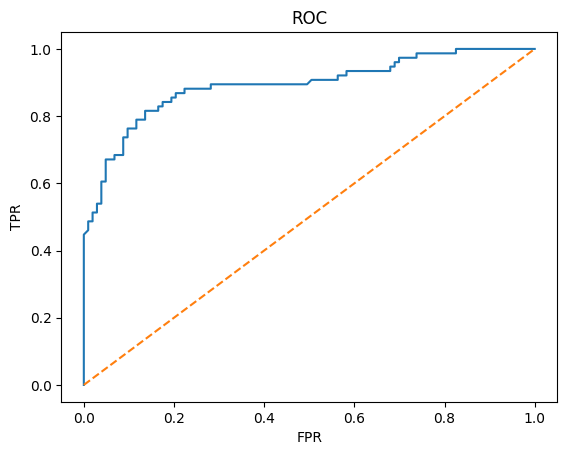

In [134]:
# probability of positive class
y_prob=model.predict_proba(X_test)[:,1]
fpr_scores, tpr_scores,thresholds=roc_curve(y_test,y_prob)


auc = roc_auc_score(y_test, y_prob)
print("AUC =", auc)

plt.plot(fpr_scores,tpr_scores)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC')
plt.savefig("roc_curve.png")
plt.show()


---
### Conclusion

The logistic regression model provides a strong baseline for predicting Titanic survival. It performs well in balancing precision and recall, and the confusion matrix helps us understand different types of prediction errors.

- Accuracy = 0.8156 → the model correctly predicts about 81.6% of all passengers.
- Precision = 0.7867 → among predicted survivors, about 78.7% actually survived.
- Recall = 0.7763 → the model correctly identifies about 77.6% of actual survivors.
- Specificity = 0.8447 → the model correctly identifies about 84.5% of passengers who did not survive.
- F1 Score = 0.7815 → precision and recall are well balanced with an overall score of 78.1%.
- FPR = 0.1553 → about 15.5% of non-survivors were incorrectly predicted as survivors.
- AUC = 0.8876 indicates excellent class separability, meaning the model distinguishes survivors from non-survivors very well.

--- 
12. Prediction on unseen data: We apply the exact same preprocessing steps (Steps 2–5) to the unseen test data to ensure feature consistency with the training set before making final predictions.

In [135]:
df_test=pd.read_csv("test.csv")
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [136]:
#Basic Inspection
df_test.info() 
df_test.isnull().sum() 

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [137]:
# Missing value Handling
df_test["Age"] = df_test["Age"].fillna(age_median)#using training data median
df_test["Embarked"] = df_test["Embarked"].fillna(embarked_mode) # using training data mode
df_test["Fare"] = df_test["Fare"].fillna(fare_median) # using training fare median
df_test.drop(columns=["Cabin"], inplace=True)

#Feature Engineering

# Family feature
df_test["FamilySize"] = df_test["SibSp"] + df_test["Parch"] + 1
df_test["IsAlone"] = (df_test["FamilySize"] == 1).astype(int)

# Fare feature
df_test["FarePerPerson"] = df_test["Fare"] / df_test["FamilySize"]
#Title feature
df_test["Title"] = df_test["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False) 
# Clean titles
df_test["Title"] = df_test["Title"].replace(["Mlle", "Ms"], "Miss")
df_test["Title"] = df_test["Title"].replace(["Mme"], "Mrs")
common_titles = ["Mr", "Mrs", "Miss"]
df_test["Title"] = df_test["Title"].apply(lambda x: x if x in common_titles else "Rare")
#Encoding
df_test = pd.get_dummies(df_test, columns=["Sex", "Embarked", "Title"], drop_first=True)
#Dropping irrelevant or less informative features
X_TEST = df_test.drop([ "Name", "Ticket", "PassengerId","SibSp", "Parch"], axis=1) 
#Scaling 
X_TEST=scaler.transform(X_TEST)

# Make a predictin on test data
y_PRED = model.predict(X_TEST)

---
13. Final Kaggle Submission:

    **Result: ACC=.78468**

In [138]:
submission = pd.DataFrame({"PassengerId": df_test["PassengerId"],"Survived": y_PRED })
submission.to_csv("submission.csv", index=False)